In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import nltk
from wordcloud import WordCloud

C:\Users\Sha\AppData\Local\Temp\ipykernel_37668\2581238935.py:1: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [7]:
df = pd.read_csv('Amazon_sentiment_analysis.csv')

Explor Data

In [8]:
df.shape[0]

40000

In [7]:
df.columns

Index(['Unnamed: 0', 'marketplace', 'customer_id', 'review_id', 'product_id',
       'product_parent', 'product_title', 'product_category', 'star_rating',
       'helpful_votes', 'total_votes', 'vine', 'verified_purchase',
       'review_headline', 'review_body', 'review_date'],
      dtype='object')

In [9]:
df.shape

(40000, 16)

In [10]:
df.head()

,Unnamed: 0,marketplace,customer_id,review_id,product_id,product_parent,product_title,product_category,star_rating,helpful_votes,total_votes,vine,verified_purchase,review_headline,review_body,review_date
0,0,US,45283875,R131LUTLVH63V2,B003FGWF04,645498686,HH54VP series,Electronics,5.0,0.0,0.0,N,Y,Works GREAT !! Easy to program for home or mob...,Works GREAT !! Easy to program for home or mob...,2015-02-06
1,1,US,23457831,R1NUKNPRX36HIX,B00JAAJ1F6,374159046,Jarv NMotion Sport Wireless Bluetooth 4.0 Ster...,Electronics,5.0,0.0,0.0,N,Y,Best Bang for Your Buck in Wireless Headphones...,Best purchase of my life. These headphones boa...,2015-05-15
2,2,US,6731054,R1VSYY38KIHPIH,B00NM4LKJG,154075815,AUSDOM M04S Over Ear Bluetooth Headphone Advan...,Electronics,5.0,1.0,1.0,N,Y,Awesome!!,Perfect my daughter love them!!!,2014-12-31
3,3,US,46880374,R3RGO8LHIKB1SF,B00ICV26DS,522586369,"Beats by Dr.Dre in Ear Head Phones, Black",Electronics,5.0,0.0,0.0,N,Y,Five Stars,Yes they did.,2014-11-30
4,4,US,34512918,R27W2ZQJOZEH3V,B0046H8ZHS,335809885,SleepPhones Classic Sleep Headphones,Electronics,5.0,0.0,0.0,N,Y,Five Stars,This has made all the difference for me with r...,2015-05-17


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         40000 non-null  int64  
 1   marketplace        40000 non-null  object 
 2   customer_id        40000 non-null  int64  
 3   review_id          40000 non-null  object 
 4   product_id         40000 non-null  object 
 5   product_parent     40000 non-null  int64  
 6   product_title      40000 non-null  object 
 7   product_category   40000 non-null  object 
 8   star_rating        40000 non-null  float64
 9   helpful_votes      40000 non-null  float64
 10  total_votes        40000 non-null  float64
 11  vine               40000 non-null  object 
 12  verified_purchase  40000 non-null  object 
 13  review_headline    39998 non-null  object 
 14  review_body        39989 non-null  object 
 15  review_date        39997 non-null  object 
dtypes: float64(3), int64(3

In [12]:
cols = df.columns
for col in cols :
    print(df[col].isnull().sum())

0
0
0
0
0
0
0
0
0
0
0
0
0
2
11
3


In [13]:
df['star_rating'].value_counts()

star_rating
5.0    16107
1.0     9500
3.0     6116
2.0     4384
4.0     3893
Name: count, dtype: int64

Data Cleaning

In [14]:
df = df.dropna()

In [16]:
df['star_rating'] = df['star_rating'].astype(float).astype(int)
df['helpful_votes'] = df['helpful_votes'].astype(float).astype(int)
df['total_votes'] = df['total_votes'].astype(float).astype(int)

Preprocessing Data

In [17]:
#drop unusefull features

col_to_drop = ['marketplace', 'review_id', 'customer_id', 'product_parent','product_id', 'product_title']
df.drop(col_to_drop, axis=1, inplace=True)

In [4]:
 #Remove HTML tags, URLs, puncuations and underscores 

def clean_text(text):
    
    text = re.sub(r'<[^>]+>', ' ', text)
    text = re.sub(r'http\S+', ' ', text)
    text = re.sub(r'[\W_]+', ' ', text)
    clean_text = re.sub(r'\s+', ' ', text).strip()
    return clean_text

In [3]:
#tokenize


def tokenize_text(text) :

    tokens = word_tokenize(text)
    tokenized_text = [token.lower() for token in tokens]
    return tokenized_text


In [8]:
#remove stop words

nltk.download('punkt')
nltk.download('stopwords')

def remove_stopWords(text) :

    stop_words = set(stopwords.words('english'))
    tokens =  word_tokenize(text)
    tokens = [token.lower() for token in tokens if token.lower() not in stop_words]
    return tokens

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Sha\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Sha\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Data Visualizaing

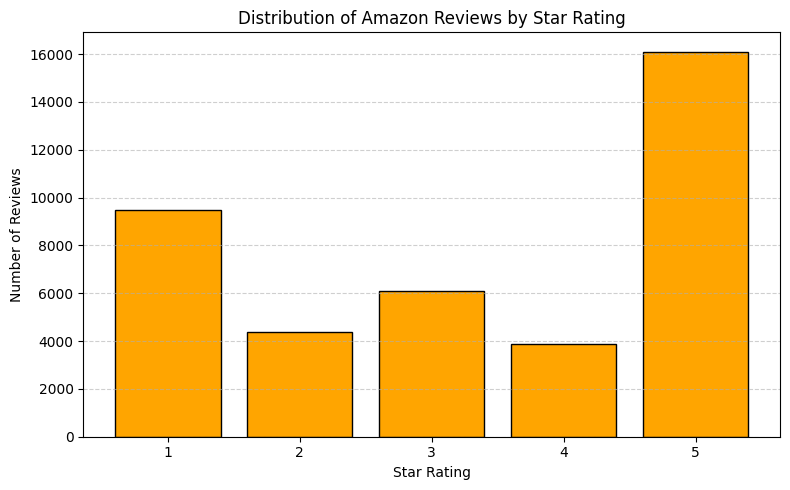

In [19]:
rating_counts = df['star_rating'].value_counts().sort_index()


plt.figure(figsize=(8, 5))
plt.bar(rating_counts.index.astype(str), rating_counts.values, color='orange', edgecolor='black')


plt.xlabel('Star Rating')
plt.ylabel('Number of Reviews')
plt.title('Distribution of Amazon Reviews by Star Rating')
plt.grid(axis='y', linestyle='--', alpha=0.6)


plt.tight_layout()
plt.show()

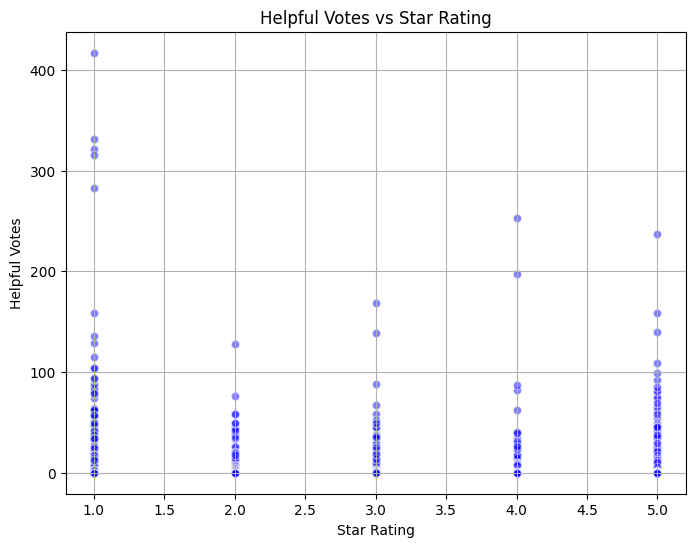

In [21]:
plt.figure(figsize=(8, 6))
plt.scatter(df['star_rating'], df['helpful_votes'], alpha=0.5, c='blue', edgecolors='w')


plt.xlabel('Star Rating')
plt.ylabel('Helpful Votes')
plt.title('Helpful Votes vs Star Rating')
plt.grid(True)


plt.show()

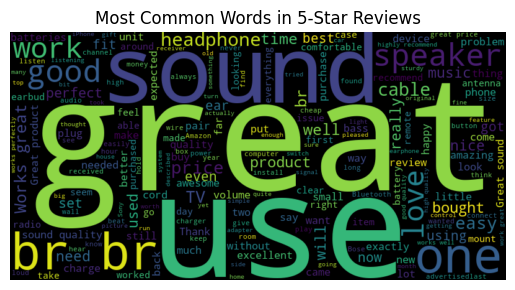

In [23]:
text_5star = " ".join(df[df['star_rating'] == 5]['review_body'])
wordcloud = WordCloud(width=800, height=400).generate(text_5star)

plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Most Common Words in 5-Star Reviews")
plt.show()